In [2]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import anndata
from glob import glob
import os
import scanpy as sc
import logging
import warnings
import statsmodels.api as sm
import statsmodels.formula.api as smf
warnings.filterwarnings('ignore')
sns.set(font_scale=1.8, style = "ticks")

# Spatial transcriptomics - ABC dataset

In [ ]:
from pathlib import Path
from abc_atlas_access.abc_atlas_cache.abc_project_cache import AbcProjectCache

download_base = Path("Merfish_ABC_data")
abc_cache = AbcProjectCache.from_cache_dir(download_base)

abc_cache.current_manifest
abc_cache.list_data_files("WMB-10Xv3")

abc_cache.get_data_path(directory="WMB-10Xv3", file_name="WMB-10Xv3-HY/log2")

WMB-10Xv3-HY-log2.h5ad:   9%|▉         | 661M/7.25G [00:41<06:13, 17.6MMB/s]     

KeyboardInterrupt: 

In [17]:
abc_cache.current_manifest

'releases/20250131/manifest.json'

In [7]:
file = abc_cache.get_data_path(directory="WMB-10Xv3", file_name="WMB-10Xv3-HY/log2")
adata = anndata.read_h5ad(file, backed="r+")
print(adata)

AnnData object with n_obs × n_vars = 162869 × 32285 backed at '/Users/caom/Documents/negative_parental_switch/NPW_transcripts/transcriptormics _merfish/Merfish_ABC_data/expression_matrices/WMB-10Xv3/20230630/WMB-10Xv3-HY-log2.h5ad'
    obs: 'cell_barcode', 'library_label', 'anatomical_division_label'
    var: 'gene_symbol'
    uns: 'normalization', 'parent', 'parent_layer', 'parent_rows'


In [3]:
cell = abc_cache.get_metadata_dataframe(
    directory="MERFISH-C57BL6J-638850",
    file_name="cell_metadata_with_cluster_annotation",
)
cell.rename(
    columns={"x": "x_section", "y": "y_section", "z": "z_section"}, inplace=True
)
cell.set_index("cell_label", inplace=True)
cell.head(5)

,brain_section_label,cluster_alias,average_correlation_score,feature_matrix_label,donor_label,donor_genotype,donor_sex,x_section,y_section,z_section,neurotransmitter,class,subclass,supertype,cluster,neurotransmitter_color,class_color,subclass_color,supertype_color,cluster_color
cell_label,,,,,,,,,,,,,,,,,,,,
1019171907102340387-1,C57BL6J-638850.37,1408,0.596276,C57BL6J-638850,C57BL6J-638850,wt/wt,M,7.226245,4.148963,6.6,NaN,04 DG-IMN Glut,038 DG-PIR Ex IMN,0141 DG-PIR Ex IMN_2,0515 DG-PIR Ex IMN_2,#666666,#16f2f2,#3D53CC,#CC7A3D,#73FFBF
1104095349101460194-1,C57BL6J-638850.26,4218,0.641180,C57BL6J-638850,C57BL6J-638850,wt/wt,M,5.064889,7.309543,4.2,Glut,23 P Glut,235 PG-TRN-LRN Fat2 Glut,0953 PG-TRN-LRN Fat2 Glut_1,4199 PG-TRN-LRN Fat2 Glut_1,#2B93DF,#6b5ca5,#9B7ACC,#990041,#663D63
1017092617101450577,C57BL6J-638850.25,4218,0.763531,C57BL6J-638850,C57BL6J-638850,wt/wt,M,5.792921,8.189973,4.0,Glut,23 P Glut,235 PG-TRN-LRN Fat2 Glut,0953 PG-TRN-LRN Fat2 Glut_1,4199 PG-TRN-LRN Fat2 Glut_1,#2B93DF,#6b5ca5,#9B7ACC,#990041,#663D63
1018093344101130233,C57BL6J-638850.13,4218,0.558073,C57BL6J-638850,C57BL6J-638850,wt/wt,M,3.195950,5.868655,2.4,Glut,23 P Glut,235 PG-TRN-LRN Fat2 Glut,0953 PG-TRN-LRN Fat2 Glut_1,4199 PG-TRN-LRN Fat2 Glut_1,#2B93DF,#6b5ca5,#9B7ACC,#990041,#663D63
1019171912201610094,C57BL6J-638850.27,4218,0.591009,C57BL6J-638850,C57BL6J-638850,wt/wt,M,5.635732,7.995842,4.4,Glut,23 P Glut,235 PG-TRN-LRN Fat2 Glut,0953 PG-TRN-LRN Fat2 Glut_1,4199 PG-TRN-LRN Fat2 Glut_1,#2B93DF,#6b5ca5,#9B7ACC,#990041,#663D63


In [4]:
reconstructed_coords = abc_cache.get_metadata_dataframe(
    directory="MERFISH-C57BL6J-638850-CCF",
    file_name="reconstructed_coordinates",
    dtype={"cell_label": str},
)
reconstructed_coords.rename(
    columns={"x": "x_reconstructed", "y": "y_reconstructed", "z": "z_reconstructed"},
    inplace=True,
)
reconstructed_coords.set_index("cell_label", inplace=True)
cell_joined = cell.join(reconstructed_coords, how="inner")

In [5]:
ccf_coords = abc_cache.get_metadata_dataframe(
    directory="MERFISH-C57BL6J-638850-CCF",
    file_name="ccf_coordinates",
    dtype={"cell_label": str},
)
ccf_coords.rename(columns={"x": "x_ccf", "y": "y_ccf", "z": "z_ccf"}, inplace=True)
ccf_coords.drop(["parcellation_index"], axis=1, inplace=True)
ccf_coords.set_index("cell_label", inplace=True)
cell_joined = cell_joined.join(ccf_coords, how="inner")

In [6]:
parcellation_annotation = abc_cache.get_metadata_dataframe(
    directory="Allen-CCF-2020",
    file_name="parcellation_to_parcellation_term_membership_acronym",
)
parcellation_annotation.set_index("parcellation_index", inplace=True)
parcellation_annotation.columns = [
    "parcellation_%s" % x for x in parcellation_annotation.columns
]
parcellation_annotation.head(5)

,parcellation_organ,parcellation_category,parcellation_division,parcellation_structure,parcellation_substructure
parcellation_index,,,,,
0,unassigned,unassigned,unassigned,unassigned,unassigned
1,brain,grey,HY,TMv,TMv
2,brain,grey,Isocortex,SSp-m,SSp-m6b
5,brain,fiber tracts,lfbs,cst,int
6,brain,grey,P,PSV,PSV


In [7]:
parcellation_color = abc_cache.get_metadata_dataframe(
    directory="Allen-CCF-2020",
    file_name="parcellation_to_parcellation_term_membership_color",
)
parcellation_color.set_index("parcellation_index", inplace=True)
parcellation_color.columns = ["parcellation_%s" % x for x in parcellation_color.columns]
parcellation_color.head(5)

,parcellation_organ_color,parcellation_category_color,parcellation_division_color,parcellation_structure_color,parcellation_substructure_color
parcellation_index,,,,,
0,#000000,#000000,#000000,#000000,#000000
1,#FFFFFF,#BFDAE3,#E64438,#FF4C3E,#FF4C3E
2,#FFFFFF,#BFDAE3,#70FF71,#188064,#188064
5,#FFFFFF,#CCCCCC,#CCCCCC,#CCCCCC,#CCCCCC
6,#FFFFFF,#BFDAE3,#FF9B88,#FFAE6F,#FFAE6F


In [8]:
cell_joined = cell_joined.join(parcellation_annotation, on="parcellation_index")
cell_joined = cell_joined.join(parcellation_color, on="parcellation_index")
cell_joined.head(5)

,brain_section_label,cluster_alias,average_correlation_score,feature_matrix_label,donor_label,donor_genotype,donor_sex,x_section,y_section,z_section,...,parcellation_organ,parcellation_category,parcellation_division,parcellation_structure,parcellation_substructure,parcellation_organ_color,parcellation_category_color,parcellation_division_color,parcellation_structure_color,parcellation_substructure_color
cell_label,,,,,,,,,,,,,,,,,,,,,
1019171907102340387-1,C57BL6J-638850.37,1408,0.596276,C57BL6J-638850,C57BL6J-638850,wt/wt,M,7.226245,4.148963,6.6,...,brain,grey,HPF,DG,DG-po,#FFFFFF,#BFDAE3,#7ED04B,#7ED04B,#7ED04B
1104095349101460194-1,C57BL6J-638850.26,4218,0.641180,C57BL6J-638850,C57BL6J-638850,wt/wt,M,5.064889,7.309543,4.2,...,brain,grey,P,TRN,TRN,#FFFFFF,#BFDAE3,#FF9B88,#FFBA86,#FFBA86
1017092617101450577,C57BL6J-638850.25,4218,0.763531,C57BL6J-638850,C57BL6J-638850,wt/wt,M,5.792921,8.189973,4.0,...,brain,grey,P,P-unassigned,P-unassigned,#FFFFFF,#BFDAE3,#FF9B88,#FF9B88,#FF9B88
1018093344101130233,C57BL6J-638850.13,4218,0.558073,C57BL6J-638850,C57BL6J-638850,wt/wt,M,3.195950,5.868655,2.4,...,brain,fiber tracts,cbf,arb,arb,#FFFFFF,#CCCCCC,#CCCCCC,#CCCCCC,#CCCCCC
1019171912201610094,C57BL6J-638850.27,4218,0.591009,C57BL6J-638850,C57BL6J-638850,wt/wt,M,5.635732,7.995842,4.4,...,brain,grey,P,P-unassigned,P-unassigned,#FFFFFF,#BFDAE3,#FF9B88,#FF9B88,#FF9B88


In [18]:
imputed_h5ad_path = abc_cache.get_data_path(
    "MERFISH-C57BL6J-638850-imputed", "C57BL6J-638850-imputed/log2"
)
adata = anndata.read_h5ad(imputed_h5ad_path, backed="r+")

C57BL6J-638850-imputed-log2.h5ad: 100%|██████████| 50.2G/50.2G [1:11:05<00:00, 11.8MMB/s]   


In [19]:
print(adata)

AnnData object with n_obs × n_vars = 4334174 × 8460 backed at '/Users/caom/Documents/negative_parental_switch/NPW_transcripts/transcriptormics _merfish/Merfish_ABC_data/expression_matrices/MERFISH-C57BL6J-638850-imputed/20240831/C57BL6J-638850-imputed-log2.h5ad'
    obs: 'brain_section_label'
    var: 'gene_symbol'


In [111]:
mpoa_list = ["MPO", "MPN", "PD", "ADP"]

filter_cells = cell_joined[
    cell_joined["parcellation_substructure"].isin(mpoa_list)
].index

In [112]:
adata.strings_to_categoricals()
filtered_adata = adata[filter_cells, :].copy(
    filename="filtered_cells.h5ad"
)  # Save filtered cells)

In [2]:
# read saved adata
import anndata

filtered_adata = anndata.read_h5ad("Merfish_ABC_data/filtered_cells.h5ad", backed="r+")

In [3]:
gene_list = [
    "Npy1r",
    "Npy2r",
    "Hcn1",
    "Hcn2",
    "Esr1",
    "Pgr",
]
filtered_df = filtered_adata[:, filtered_adata.var["gene_symbol"].isin(gene_list)]

In [4]:
gene_dict = pd.Series(
    filtered_df.var.index, index=filtered_df.var.gene_symbol
).to_dict()

In [21]:
filtered_df.to_df().head(5)


# percentage of colocalization
def colocalization(df, gene_list, threshold=1):
    ensemblr = [gene_dict[gene] for gene in gene_list]
    colocalized = (df.loc[:, ensemblr] >= threshold).all(axis=1)
    colocalized_percentage = colocalized.mean() * 100

    return colocalized_percentage


def conditioned_localization(df, either_lists, and_list, threshold=1):
    eithers = []
    for either_list in either_lists:
        ensemblr = [gene_dict[gene] for gene in either_list]
        either = (df.loc[:, ensemblr] >= threshold).any(axis=1)
        eithers.append(either)

    ensemblr_and = [gene_dict[gene] for gene in and_list]
    and_positive = (df.loc[:, ensemblr_and] >= threshold).all(axis=1)

    # Combine both conditions with AND
    condition = eithers[0] & eithers[1] & and_positive
    # Calculate percentage of cells where both conditions are true
    colocalization_percentage = condition.mean() * 100
    return colocalization_percentage


npy_either_list = ["Npy1r", "Npy2r"]
hcn_either_list = ["Hcn1", "Hcn2"]

and_list = ["Esr1", "Pgr"]


colocalization_results = colocalization(
    filtered_df.to_df().copy(), ["Npy1r", "Esr1", "Pgr", "Hcn1"]
)
cond_colocalization_results = conditioned_localization(
    filtered_df.to_df().copy(), [npy_either_list, hcn_either_list], and_list
)

npyr_and_hcn = conditioned_localization(
    filtered_df.to_df().copy(), [npy_either_list, hcn_either_list], []
)
npyr_and_hcn = pd.DataFrame({
    "gene": "Npy1/2r + HCN1/2",
    "threshold":1,
    "percentage": [npyr_and_hcn]
})
npyr_and_hcn_2 = conditioned_localization(
    filtered_df.to_df().copy(), [npy_either_list, hcn_either_list], [], threshold=2
)

npyr_and_hcn_2 = pd.DataFrame({
    "gene": "Npy1/2r + HCN1/2",
    "threshold": 2,
    "percentage": [npyr_and_hcn_2]
})

npyr_and_hcn_3 = conditioned_localization(
    filtered_df.to_df().copy(), [npy_either_list, hcn_either_list], [], threshold=3
)

npyr_and_hcn_3 = pd.DataFrame({
    "gene": "Npy1/2r + HCN1/2",
    "threshold": 3,
    "percentage": [npyr_and_hcn_3]
})
npyr_and_hcns = pd.concat([npyr_and_hcn, npyr_and_hcn_2, npyr_and_hcn_3], ignore_index=True)
print("Colocalization percentage:", colocalization_results)
print("Conditioned colocalization percentage:", cond_colocalization_results)
print("Conditioned colocalization with NPY and HCN:", npyr_and_hcn)

Colocalization percentage: 38.82066600287642
Conditioned colocalization percentage: 46.66445403252572
Conditioned colocalization with NPY and HCN:                gene  threshold  percentage
0  Npy1/2r + HCN1/2          1   55.017148


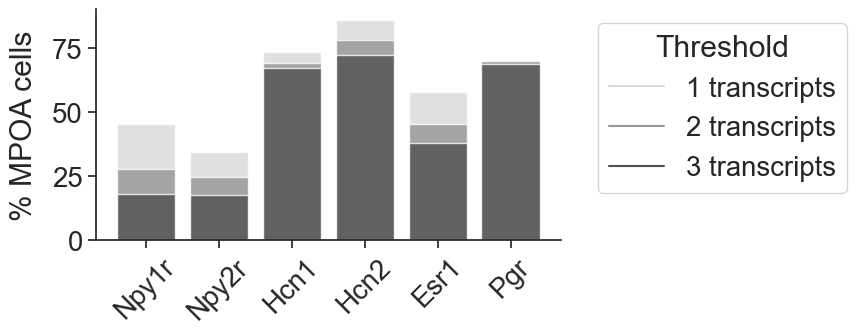

In [22]:
def obtain_percentage_with_different_thresholds(df, gene_list, thresholds):
    percentages = pd.DataFrame(columns=["gene", "threshold", "percentage"])
    for gene in gene_list:
        for threshold in thresholds:
            percentage = colocalization(df, [gene], threshold)
            percentages = pd.concat(
                [
                    percentages,
                    pd.DataFrame(
                        {
                            "gene": [gene],
                            "threshold": [threshold],
                            "percentage": [percentage],
                        }
                    ),
                ],
                ignore_index=True,
            )
    return percentages


thresholds = [1, 2, 3]
gene_list = ["Npy1r", "Npy2r", "Hcn1", "Hcn2",  "Esr1", "Pgr"]
percentages = obtain_percentage_with_different_thresholds(
    filtered_df.to_df().copy(), gene_list, thresholds
)


plt.subplots(figsize=(6, 3))


plt.bar(
    percentages["gene"],
    percentages["percentage"],
    color=sns.color_palette("Grays", n_colors=len(thresholds)),
    alpha=0.8,
)

sns.despine()
# legend
for t in thresholds:
    plt.plot([], [], color=sns.color_palette("Grays", n_colors=len(thresholds))[t-1], label=f"{t} transcripts")
    
plt.legend(
    title="Threshold",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
)
plt.ylabel("% MPOA cells", labelpad=10)
plt.xticks(rotation=45)
plt.savefig("output_figures/percentage_expression_thresholds.pdf", bbox_inches='tight', dpi=300, transparent=True)

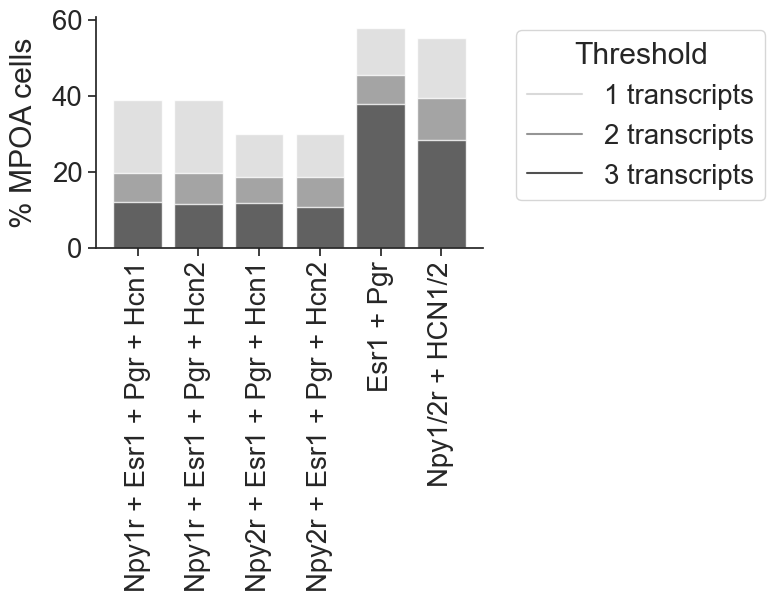

In [23]:
def colocalization_with_thresholds(df, gene_list, thresholds):
    results = pd.DataFrame(columns=["gene", "percentage", 'threshold'])
    for threshold in thresholds:
        colocalization_percentage = colocalization(df, gene_list, threshold)
        combination_name = " + ".join(gene_list)
        results = pd.concat(
            [
                results,
                pd.DataFrame(
                    {
                        "gene": [combination_name],
                        "percentage": [colocalization_percentage],
                        'threshold': [threshold]
                    }
                ),
            ],
            ignore_index=True,
        )
    return results

npy1r_pgr_esr1_hcn1 = colocalization_with_thresholds(filtered_df.to_df().copy(), ["Npy1r", "Esr1", "Pgr", "Hcn1"], thresholds)
npy1r_pgr_esr1_hcn2 = colocalization_with_thresholds(filtered_df.to_df().copy(), ["Npy1r", "Esr1", "Pgr", "Hcn2"], thresholds)
npy2r_pgr_esr1_hcn1 = colocalization_with_thresholds(filtered_df.to_df().copy(), ["Npy2r", "Esr1", "Pgr", "Hcn1"], thresholds)
npy2r_pgr_esr1_hcn2 = colocalization_with_thresholds(filtered_df.to_df().copy(), ["Npy2r", "Esr1", "Pgr", "Hcn2"], thresholds)

pgr_esr1 = colocalization_with_thresholds(filtered_df.to_df().copy(), ["Esr1", "Pgr"], thresholds)
# pgr_esr1_hcn1 = colocalization_with_thresholds(filtered_df.to_df().copy(), ["Esr1", "Pgr", "Hcn1"], thresholds)
# pgr_esr1_hcn2 = colocalization_with_thresholds(filtered_df.to_df().copy(), ["Esr1", "Pgr", "Hcn2"], thresholds)


colocalization_results = pd.concat([
    npy1r_pgr_esr1_hcn1,
    npy1r_pgr_esr1_hcn2,
    npy2r_pgr_esr1_hcn1,
    npy2r_pgr_esr1_hcn2,
    pgr_esr1,
    npyr_and_hcns,
    # pgr_esr1_hcn1,
    # pgr_esr1_hcn2
], ignore_index=True)


plt.subplots(figsize=(5, 3))
plt.bar(
    colocalization_results["gene"],
    colocalization_results["percentage"],
    color=sns.color_palette("Grays", n_colors=len(thresholds)),
    alpha=0.8,
)

for t in thresholds:
    plt.plot([], [], color=sns.color_palette("Grays", n_colors=len(thresholds))[t-1], label=f"{t} transcripts")
    
plt.legend(
    title="Threshold",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
)
plt.ylabel("% MPOA cells", labelpad=10)
sns.despine()
plt.xticks(rotation=90)

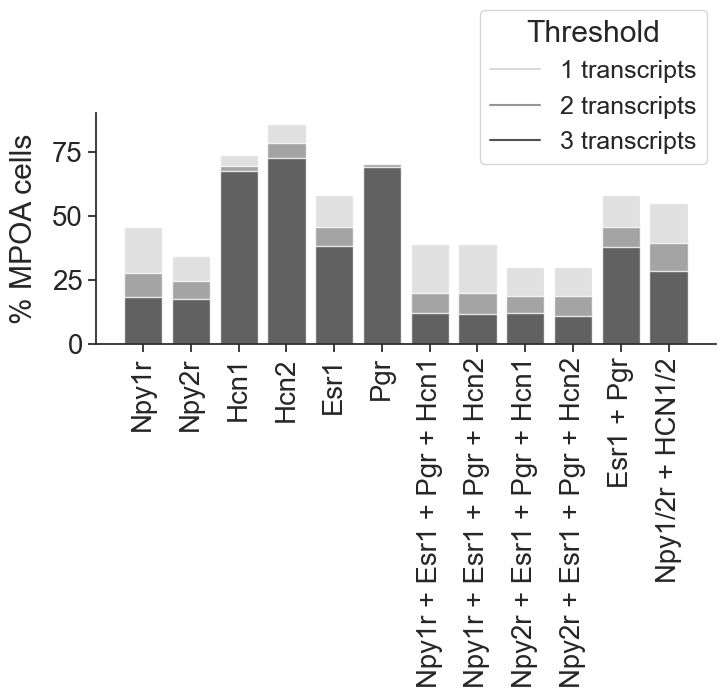

In [24]:
all_percentages = pd.concat([percentages, colocalization_results], ignore_index=True)

plt.subplots(figsize=(8, 3))
plt.bar(
    all_percentages["gene"],
    all_percentages["percentage"],
    color=sns.color_palette("Grays", n_colors=len(thresholds)),
    alpha=0.8,
)
for t in thresholds:
    plt.plot([], [], color=sns.color_palette("Grays", n_colors=len(thresholds))[t-1], label=f"{t} transcripts")
plt.legend(
    title="Threshold",
    bbox_to_anchor=(0.6, 1.5),
    loc="upper left",
    fontsize='small',
)
plt.ylabel("% MPOA cells", labelpad=10)
plt.xticks(rotation = 90)
sns.despine()

In [25]:

from upsetplot import UpSet

def plot_normalized_upset(sets, labels, title=None, figsize=(11, 5), category_order=None):

    all_elements = set().union(*sets)
    matrix = pd.DataFrame(index=list(all_elements))

    for label, s in zip(labels, sets):
        matrix[label] = matrix.index.isin(s)
    
    if category_order:
        matrix = matrix[category_order]

    group_counts = matrix.groupby(labels).size()
    total_counts = filtered_df.to_df().shape[0]
    normalized_counts = group_counts / total_counts *100
    

    # Create a figure with large size
    fig = plt.figure(figsize=figsize)

    # Plot to it — upsetplot will use default axes unless we re-tighten
    upset = UpSet(normalized_counts, show_percentages=True,  sort_categories_by=None)
    upset.plot(fig=fig)

    for ax in fig.axes:
        for txt in ax.texts:
            if '%' in txt.get_text():
                txt.set_fontsize(14)
            
                # You can also adjust position:
                # x, y = txt.get_position()
                # txt.set_position((x, y+0.02))

    if title:
        fig.suptitle(title, y=1.02)

    # Manual layout adjustment that *does* work
    fig.set_size_inches(figsize)  # <-- force figure size again
    plt.ylabel("%MPOA cells", labelpad=10)
    # fig.tight_layout()
    plt.show()
    


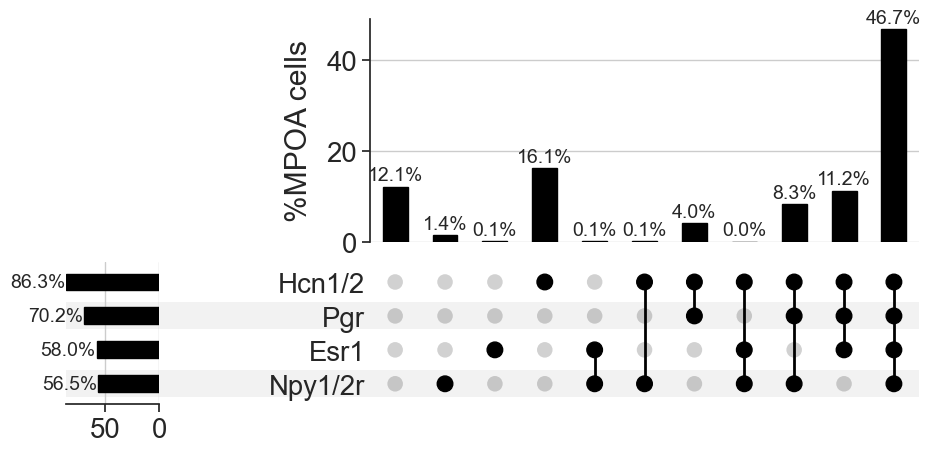

In [69]:
# Create sets
npy1r = set(filtered_df.to_df().copy().loc[:, gene_dict["Npy1r"]][lambda x: x >= 1].index)
npy2r = set(filtered_df.to_df().copy().loc[:, gene_dict["Npy2r"]][lambda x: x >= 1].index)

npyr = npy1r.union(npy2r)
hcn1  = set(filtered_df.to_df().copy().loc[:, gene_dict["Hcn1"]][lambda x: x >= 1].index)
hcn2  = set(filtered_df.to_df().copy().loc[:, gene_dict["Hcn2"]][lambda x: x >= 1].index)
hcn = hcn1.union(hcn2)
esr1 = set(filtered_df.to_df().copy().loc[:, gene_dict["Esr1"]][lambda x: x >= 1].index)
pgr = set(filtered_df.to_df().copy().loc[:, gene_dict["Pgr"]][lambda x: x >= 1].index)
everything_else = set(filtered_df.to_df().copy().index) - npyr - esr1 - pgr - hcn

# Plot
plot_normalized_upset(
    sets=[npyr,  esr1, pgr, hcn, everything_else],
    labels=["Npy1/2r", "Esr1","Pgr", "Hcn1/2"],
    category_order=["Npy1/2r", "Esr1", "Pgr", "Hcn1/2"],
)



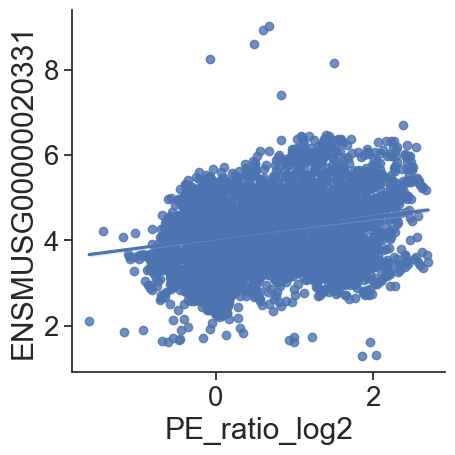

In [137]:
corr_df = filtered_df.to_df()
ensemblr_and = [gene_dict[gene] for gene in and_list]
and_positive = corr_df[(corr_df.loc[:, ensemblr_and] >= 1).all(axis=1)]

and_positive["PE_ratio"] = and_positive[ensemblr_and[1]] / and_positive[ensemblr_and[0]]
and_positive["PE_ratio_log2"] = np.log2(and_positive["PE_ratio"])

gene = "ENSMUSG00000020331"
sns.lmplot(data=and_positive, x="PE_ratio_log2", y=gene)

In [49]:
smf.ols(formula="{} ~ PE_ratio_log2".format(gene), data=and_positive).fit().summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:     ENSMUSG00000020331   R-squared:                       0.054
Model:                            OLS   Adj. R-squared:                  0.054
Method:                 Least Squares   F-statistic:                     300.0
Date:                Sun, 29 Jun 2025   Prob (F-statistic):           2.11e-65
Time:                        22:22:49   Log-Likelihood:                -6154.7
No. Observations:                5230   AIC:                         1.231e+04
Df Residuals:                    5228   BIC:                         1.233e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         4.0570      0.013    317.092      0.000       4.032       4.082
PE_ratio_log2     0.2428      0.014     17.321      0.000       0.215       0.270
==============================================================================
Omnibus:                       77.381   Durbin-Watson:                   0.663
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              112.924
Skew:                           0.169   Prob(JB):                     3.01e-25
Kurtosis:                       3.636   Cond. No.                         1.82
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""